# Amodal surface pipeline (short, YOLO-World + Gemini nano banana)

Full pipeline inline (same code as `run.py`, but object detection = **YOLO-World**
instead of RAM++/GroundingDINO). Recovers the **amodal** wall/floor (incl. parts
hidden behind furniture) by detecting on a Gemini nano-banana-generated empty room.

Per sample (`output-test/<SAMPLE>/`):

1. **YOLO-World** open-vocab detection (fixed `YOLO_CLASSES` prompt) -> object
   bboxes (built-in NMS), then **BiRefNet** mattes the foreground inside each box
   -> object mask + **rug** mask (things to remove)
2. **Gemini nano banana** (2.5 Flash Image) -> inpaint-remove objects AND rug -> empty room
3. **image2scene API** (`auto_detect`) on the empty room -> amodal wall/floor masks
4. **visible** = amodal surface - objects; **floor** also - rug

Unlike Imagen inpaint, nano banana edits from a prompt (no mask API), so pixels
OUTSIDE the mask are not guaranteed byte-identical and the empty room may drift
slightly; image2scene re-runs on it so masks still align. Needs `birefnet` conda
env + `ultralytics` + `GEMINI_API_KEY` in `.env`.

## Imports & config

In [ ]:
import os, sys, json
from pathlib import Path

import numpy as np
import cv2
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from dotenv import load_dotenv
import matplotlib.pyplot as plt

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "users"
BIREFNET_REPO = ROOT / "hq-mat" / "BiRefNet"
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backend.mps.is_available() else "cpu")

# YOLO-World open-vocab detection (replaces RAM++ auto-tag + GroundingDINO).
# YOLO-World has no auto-tagger, so the vocabulary is a FIXED class list set once
# via yolo.set_classes(YOLO_CLASSES). Structural surfaces are intentionally absent.
YOLO_WORLD_WEIGHTS = ROOT / "yolov8m-worldv2.pt"
YOLO_CONF = 0.05    # keep low: BiRefNet matte refines the box, so favour recall
YOLO_IOU = 0.5      # built-in NMS: drop boxes overlapping > this IoU
YOLO_CLASSES = [
    "furniture", "chair", "table", "sofa", "couch", "bed", "cabinet", "shelf",
    "lamp", "light", "potted plant", "rug", "pillow", "curtain", "television",
    "picture frame", "mirror", "vase", "appliance", "box", "decoration",
]
# YOLO labels treated as rug/floor-covering (own removal + floor-visible subtract)
RUG_LABELS = ("rug", "carpet", "mat", "runner")

NANO_EDIT_MODEL = "gemini-2.5-flash-image"   # "nano banana" (Gemini 2.5 Flash Image)
# nano banana has no mask/inpaint API, so the instruction prompt does the removal.
NANO_INPAINT_PROMPT = (
    "You are a virtual home-staging tool. Remove ALL movable objects from this room "
    "photo \u2014 furniture, rugs, decor, plants, lamps, curtains, pillows, wall art, "
    "appliances \u2014 leaving an empty room with only bare walls, floor, ceiling, "
    "windows and doors. Realistically fill the vacated areas to match the room's "
    "lighting, perspective and materials. Keep the camera framing and resolution "
    "identical to the input."
)

# heavy models, filled by load_models()
_bi = _bi_tf = yolo = genai_client = None


## IO helpers

In [ ]:
def load_sample(sample_dir: Path):
    """Load original image for one sample folder (no auto_detect.json needed:
    objects+rug come from YOLO-World, wall/floor from the API re-run)."""
    return Image.open(sample_dir / "original.jpg").convert("RGB")


def mask_to_pil(mask) -> Image.Image:
    """Boolean/float mask -> 8-bit L image (255 = surface)."""
    return Image.fromarray((np.asarray(mask) > 0).astype(np.uint8) * 255, mode="L")


## Load models (BiRefNet + YOLO-World + Gemini nano banana)

In [ ]:
def load_models():
    """Load BiRefNet + YOLO-World + the Gemini nano-banana client (once)."""
    global _bi, _bi_tf, yolo, genai_client

    # env / Gemini Developer API auth (api key, NOT Vertex ADC)
    load_dotenv(override=True)
    api_key = os.environ.get("GEMINI_API_KEY")
    assert api_key, "Put GEMINI_API_KEY=<key> in .env (Gemini Developer API)"

    torch.set_float32_matmul_precision("high")

    # BiRefNet (local repo)
    if str(BIREFNET_REPO) not in sys.path:
        sys.path.insert(0, str(BIREFNET_REPO))
    from models.birefnet import BiRefNet
    _bi = BiRefNet.from_pretrained("zhengpeng7/birefnet").to(device).eval()
    _bi_tf = transforms.Compose([
        transforms.Resize((1024, 1024)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    # YOLO-World (open-vocab detection; vocabulary fixed via set_classes)
    from ultralytics import YOLO
    yolo = YOLO(str(YOLO_WORLD_WEIGHTS))
    yolo.set_classes(YOLO_CLASSES)

    # Gemini 2.5 Flash Image ("nano banana") via google-genai Developer API
    from google import genai
    genai_client = genai.Client(api_key=api_key)

    print(f"models ready on {device} | yolo classes={len(YOLO_CLASSES)} | nano-banana ready")


load_models()


## 1. YOLO-World boxes -> BiRefNet object + rug mask

In [ ]:
@torch.no_grad()
def _birefnet_crop(image: Image.Image, box):
    """BiRefNet foreground for one crop, pasted back onto a full-image canvas."""
    w, h = image.size
    x1, y1, x2, y2 = (int(round(v)) for v in box)
    x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
    canvas = np.zeros((h, w), dtype=np.float32)
    if x2 <= x1 or y2 <= y1:
        return canvas
    pred = _bi(_bi_tf(image.crop((x1, y1, x2, y2))).unsqueeze(0).to(device))
    pred = pred[-1].sigmoid().cpu()[0, 0]
    canvas[y1:y2, x1:x2] = F.interpolate(pred[None, None], size=(y2 - y1, x2 - x1),
                                         mode="bilinear", align_corners=True)[0, 0].numpy()
    return canvas


def detect_objects(image: Image.Image, conf=YOLO_CONF, iou=YOLO_IOU):
    """YOLO-World open-vocab -> ([x1,y1,x2,y2] boxes, labels) for room objects.
    Vocabulary is the fixed YOLO_CLASSES list set once in load_models via
    yolo.set_classes(); built-in NMS (iou) drops redundant overlapping boxes."""
    r = yolo.predict(image, conf=conf, iou=iou, device=device, verbose=False)[0]
    boxes = [[float(v) for v in b] for b in r.boxes.xyxy.cpu().tolist()]
    labels = [r.names[int(c)] for c in r.boxes.cls.cpu().tolist()]
    return boxes, labels


def birefnet_objects(image: Image.Image, boxes, pad=0.05, full_fallback=True):
    """Object matte (float) = union of BiRefNet foreground inside each YOLO box.
    `pad` grows each box a bit; `full_fallback` also unions a full-image pass to
    catch objects YOLO may have missed."""
    w, h = image.size
    out = (_birefnet_crop(image, (0, 0, w, h)) if full_fallback
           else np.zeros((h, w), dtype=np.float32))
    for x1, y1, x2, y2 in (boxes or []):
        bw, bh = x2 - x1, y2 - y1
        out = np.maximum(out, _birefnet_crop(
            image, (x1 - pad*bw, y1 - pad*bh, x2 + pad*bw, y2 + pad*bh)))
    return out


def rug_boxes_from_labels(boxes, labels):
    """Pick the YOLO boxes whose label is a rug/floor-covering (RUG_LABELS)."""
    return [b for b, l in zip(boxes, labels)
            if any(k in str(l).lower() for k in RUG_LABELS)]


def birefnet_rug(image: Image.Image, rug_bboxes, thresh=0.5):
    """Rug footprint = BiRefNet foreground inside each rug bbox."""
    w, h = image.size
    r = np.zeros((h, w), dtype=bool)
    for b in (rug_bboxes or []):
        r |= _birefnet_crop(image, b) >= thresh
    return r


## 2. Gemini nano-banana empty room (inpaint-remove objects + rug)

In [30]:
def imagen_empty_room(sample_dir: Path, base_img, remove_mask, out_path):
    """Empty the room via Gemini 2.5 Flash Image ("nano banana"); save resized to
    base size.

    No mask: nano banana edits from the prompt + original photo only. The prompt
    (NANO_INPAINT_PROMPT) names what to remove, so remove_mask is ignored here.
    Pixels are NOT guaranteed byte-identical to the input (unlike Imagen inpaint),
    so the empty room may drift; image2scene re-runs on it so masks still align."""
    import io
    from google.genai import types
    w, h = base_img.size

    resp = genai_client.models.generate_content(
        model=NANO_EDIT_MODEL,
        contents=[NANO_INPAINT_PROMPT, base_img.convert("RGB")],
        config=types.GenerateContentConfig(response_modalities=["IMAGE"]),
    )
    empty = None
    for part in resp.candidates[0].content.parts:
        if getattr(part, "inline_data", None) is not None:
            empty = Image.open(io.BytesIO(part.inline_data.data)).convert("RGB")
            break
    if empty is None:
        raise RuntimeError("nano banana returned no image part")
    if empty.size != (w, h):                   # align to original so json points match
        empty = empty.resize((w, h), Image.LANCZOS)
    empty.save(out_path)
    return empty

## 3. image2scene API auto-detect (wall/floor masks) on the nano-banana empty room

In [ ]:
# --- image2scene API: re-run auto_detect on the nano-banana empty room ------------
import time, io, zipfile, base64, requests

API_BASE = "https://image2scene-dev.wedolabs.net"

def api_autodetect(empty_path, out_dir, do_masked_images=True, poll=2.0, timeout=300):
    """POST the empty room to image2scene /run, poll /jobs/{id}, download the result
    zip and extract EVERY file into out_dir ('from-api'). Returns
    (auto_detect dict, api downsample PIL.Image, job_id)."""
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    with open(empty_path, "rb") as f:
        r = requests.post(
            f"{API_BASE}/run",
            files={"input_image": (Path(empty_path).name, f, "image/png")},
            data={"do_masked_images": str(do_masked_images).lower()}, timeout=60)
    r.raise_for_status()
    job_id = r.json()["job_id"]
    deadline = time.time() + timeout
    while True:
        j = requests.get(f"{API_BASE}/jobs/{job_id}", timeout=30).json()
        if j["status"] == "completed":
            break
        if j["status"] == "failed":
            raise RuntimeError(f"image2scene job {job_id} failed: {j.get('message')}")
        if time.time() > deadline:
            raise TimeoutError(f"image2scene job {job_id} timed out (last={j['status']})")
        time.sleep(poll)
    zb = requests.get(j["result_zip_url"], timeout=120).content
    with zipfile.ZipFile(io.BytesIO(zb)) as z:
        z.extractall(out_dir)
    with open(out_dir / "auto_detect.json") as f:
        meta = json.load(f)
    api_img = Image.open(out_dir / "downsample.jpg").convert("RGB")
    print(f"  api job {job_id} -> {out_dir} ({len(list(out_dir.rglob('*')))} files)")
    return meta, api_img, job_id


def moge_start(image_path):
    """Kick off a MoGe (monocular geometry) job on `image_path`; return job_id.
    Async: does NOT wait. Call moge_fetch(job_id, ...) later to collect the result.
    Run on the ORIGINAL original.jpg (not the empty room)."""
    mime = "image/png" if str(image_path).lower().endswith(".png") else "image/jpeg"
    with open(image_path, "rb") as f:
        r = requests.post(
            f"{API_BASE}/run_moge",
            files={"input_image": (Path(image_path).name, f, mime)}, timeout=60)
    r.raise_for_status()
    return r.json()["job_id"]


def moge_fetch(job_id, out_dir, poll=2.0, timeout=300):
    """Poll the MoGe job started by moge_start(); download + extract its result zip
    into out_dir. Returns out_dir."""
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    deadline = time.time() + timeout
    while True:
        j = requests.get(f"{API_BASE}/jobs/{job_id}", timeout=30).json()
        if j["status"] == "completed":
            break
        if j["status"] == "failed":
            raise RuntimeError(f"moge job {job_id} failed: {j.get('message')}")
        if time.time() > deadline:
            raise TimeoutError(f"moge job {job_id} timed out (last={j['status']})")
        time.sleep(poll)
    zb = requests.get(j["result_zip_url"], timeout=120).content
    with zipfile.ZipFile(io.BytesIO(zb)) as z:
        z.extractall(out_dir)
    print(f"  moge job {job_id} -> {out_dir} ({len(list(out_dir.rglob('*')))} files)")
    return out_dir


def _rescale_meta(meta, src_size, dst_size):
    """Scale bboxes/points from the API downsample space to dst (original) space.
    No-op when sizes already match."""
    (sw, sh), (dw, dh) = src_size, dst_size
    sx, sy = dw / sw, dh / sh
    if (sx, sy) == (1.0, 1.0):
        return meta
    out = dict(meta)
    for k in ("wall_bboxes", "floor_bboxes", "rug_bboxes", "door_bboxes"):
        out[k] = [[b[0]*sx, b[1]*sy, b[2]*sx, b[3]*sy] for b in (meta.get(k) or [])]
    for k in ("wall_selected_points", "floor_selected_points", "door_selected_points"):
        out[k] = [[p[0]*sx, p[1]*sy] for p in (meta.get(k) or [])]
    return out


def _decode_masks_list(b64_list, dst_size):
    """Decode API base64 masks individually -> list of bool arrays at dst_size (W, H).
    Masks come at the API downsample size; resize (nearest) to dst."""
    W, H = dst_size
    out = []
    for b in (b64_list or []):
        raw = b.split(",", 1)[1] if b.startswith("data:") else b
        m = Image.open(io.BytesIO(base64.b64decode(raw))).convert("L")
        if m.size != (W, H):
            m = m.resize((W, H), Image.NEAREST)
        out.append(np.asarray(m) > 127)
    return out


def _decode_masks(b64_list, dst_size):
    """Union of API base64 masks -> bool array at dst_size (W, H)."""
    masks = _decode_masks_list(b64_list, dst_size)
    if not masks:
        return np.zeros(dst_size[::-1], dtype=bool)
    return np.logical_or.reduce(masks)

## 4. Full pipeline

In [ ]:
import time

# Distinct overlay colours, one per individual wall (cycled if more walls than colours)
WALL_COLORS = [(230, 25, 75), (245, 130, 48), (255, 225, 25), (0, 130, 200),
               (66, 212, 244), (145, 30, 180), (240, 50, 230), (170, 110, 40)]
FLOOR_COLOR = (60, 180, 75)


def run_pipeline(sample_dir: Path, thresh=0.5):
    """MoGe (original) -> YOLO-World -> BiRefNet -> nano-banana empty room -> image2scene
    API auto_detect (wall/floor masks, NO SAM) -> subtract objects + rug. MoGe is
    kicked off first on the ORIGINAL image and collected at the last step (runs in
    parallel). Per-surface visible masks ->
    sample_dir/masked_images/{wall,floor}_mask_visible_NN.png.
    Per-stage + total timing -> sample_dir/time.txt."""
    img = load_sample(sample_dir)
    w, h = img.size

    timings = {}                                  # stage name -> seconds
    t0 = time.time()

    def _t(name, since):
        timings[name] = time.time() - since
        print(f"  {name} done in {timings[name]:.1f}s")
        return time.time()

    # 0. kick off MoGe on the ORIGINAL image (async; collected at the last step,
    #    so it runs in parallel with BiRefNet/nano-banana/auto_detect)
    start = time.time()
    moge_job = moge_start(sample_dir / "downsample.jpg")
    start = _t("moge_start", start)

    # 1. YOLO-World open-vocab detection -> BiRefNet matte
    obj_boxes, obj_labels = detect_objects(img)
    rug_boxes = rug_boxes_from_labels(obj_boxes, obj_labels)
    objects = birefnet_objects(img, obj_boxes) >= thresh
    rug = birefnet_rug(img, rug_boxes, thresh=thresh)
    remove = objects | rug
    start = _t("yolo_birefnet", start)

    # 2. empty room (nano-banana inpaint-removal of objects AND rug)
    empty = imagen_empty_room(sample_dir, img, remove,
                              sample_dir / "empty_imagen.png")
    start = _t("nano_empty_room", start)

    # 2b. auto_detect on the empty room via image2scene -> wall/floor masks
    api_meta, _, _ = api_autodetect(sample_dir / "empty_imagen.png",
                                    sample_dir / "from-api")
    start = _t("api_autodetect", start)

    # 3. amodal wall/floor = API masks (resized to original pixel space).
    #    walls AND floors kept INDIVIDUALLY (one mask per surface).
    walls_full = _decode_masks_list(api_meta.get("wall_masks"), (w, h))
    floors_full = _decode_masks_list(api_meta.get("floor_masks"), (w, h))
    wall_full = (np.logical_or.reduce(walls_full) if walls_full
                 else np.zeros((h, w), dtype=bool))
    floor_full = (np.logical_or.reduce(floors_full) if floors_full
                  else np.zeros((h, w), dtype=bool))

    # 4. visible = full surface minus objects; floor also minus rug
    walls_vis = [wm & ~objects for wm in walls_full]           # per-wall visible
    floors_vis = [fm & ~objects & ~rug for fm in floors_full]  # per-floor visible
    wall_vis = wall_full & ~objects                            # union visible
    floor_vis = floor_full & ~objects & ~rug
    start = _t("decode_visible", start)

    out = {
        "object_mask_birefnet.png": objects,
        "rug_mask_birefnet.png": rug,
        "wall_mask_amodal.png": wall_full,
        "floor_mask_amodal.png": floor_full,
        "wall_mask_visible.png": wall_vis,
        "floor_mask_visible.png": floor_vis,
    }
    for name, m in out.items():
        mask_to_pil(m).save(sample_dir / name)

    # independent (per-surface) visible masks -> masked_images/{wall,floor}_mask_visible_NN.png
    mi_dir = sample_dir / "masked_images"
    mi_dir.mkdir(parents=True, exist_ok=True)
    for i, wm in enumerate(walls_vis, 1):
        mask_to_pil(wm).save(mi_dir / f"wall_mask_visible_{i:02d}.png")
    for i, fm in enumerate(floors_vis, 1):
        mask_to_pil(fm).save(mi_dir / f"floor_mask_visible_{i:02d}.png")

    # overlay: input + each wall in its own colour + floor (green)
    overlay = np.asarray(img).astype(np.float32)
    layers = [(wm, WALL_COLORS[i % len(WALL_COLORS)]) for i, wm in enumerate(walls_vis)]
    layers.append((floor_vis, FLOOR_COLOR))
    for m, rgb in layers:
        sel = (np.asarray(m) > 0)[..., None]
        overlay = np.where(sel, 0.5 * overlay + 0.5 * np.array(rgb), overlay)
    Image.fromarray(overlay.clip(0, 255).astype(np.uint8)).save(sample_dir / "overlay.png")
    start = _t("save_masks_overlay", start)

    # last step: collect the MoGe geometry started at step 0
    moge_dir = moge_fetch(moge_job, sample_dir / "moge")
    start = _t("moge_fetch", start)

    # per-stage + total timing -> time.txt
    timings["total"] = time.time() - t0
    lines = [f"{name:<20s} {secs:8.2f}s" for name, secs in timings.items()]
    (sample_dir / "time.txt").write_text("\n".join(lines) + "\n")
    print(f"  TOTAL {timings['total']:.1f}s -> {sample_dir / 'time.txt'}")

    return {"img": img, "empty": empty, "objects": objects, "rug": rug, "moge_dir": moge_dir,
            "timings": timings,
            "obj_boxes": obj_boxes, "obj_labels": obj_labels, "rug_boxes": rug_boxes,
            "wall_full": wall_full, "floor_full": floor_full,
            "walls_visible": walls_vis, "floors_visible": floors_vis,
            "wall_visible": wall_vis, "floor_visible": floor_vis}

## Run on one sample

In [38]:
SAMPLE = "user_10"          # any folder under output-test/

res = run_pipeline(OUTPUT_DIR / SAMPLE, thresh=0.5)
print("done:", SAMPLE)

  moge_start done in 0.3s
  ram_dino_birefnet done in 3.4s
  imagen_empty_room done in 11.7s
  api job 35328b1a-b619-46e0-8e68-23af52c8f2b6 -> /home/krist/works/refine-mask/users/user_10/from-api (11 files)
  api_autodetect done in 9.0s
  decode_visible done in 0.0s
  save_masks_overlay done in 0.2s
  moge job 3bfb8706-b441-49f2-802d-9f52e2fff735 -> /home/krist/works/refine-mask/users/user_10/moge (10 files)
  moge_fetch done in 1.6s
  TOTAL 26.2s -> /home/krist/works/refine-mask/users/user_10/time.txt
done: user_10


## YOLO-World detected objects (fixed YOLO_CLASSES prompt -- all bboxes + labels)

In [ ]:
# All YOLO-World object boxes over the input (tune YOLO_CLASSES / YOLO_CONF / YOLO_IOU)
boxes, labels = res["obj_boxes"], res["obj_labels"]
print(f"YOLO classes ({len(YOLO_CLASSES)}): {YOLO_CLASSES}")
print(f"{len(boxes)} boxes")
cmap = plt.get_cmap("tab20")
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(res["img"])
for i, (lab, (x1, y1, x2, y2)) in enumerate(zip(labels, boxes)):
    c = cmap(i % 20)
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                               fill=False, edgecolor=c, lw=2))
    ax.text(x1, max(0, y1 - 4), lab, color="white", fontsize=9,
            bbox=dict(facecolor=c, edgecolor="none", pad=1, alpha=0.85))
ax.set_title(f"YOLO-World: {len(boxes)} objects  |  {SAMPLE}")
ax.axis("off")
plt.tight_layout(); plt.show()


## Inputs (YOLO-World object/rug boxes) & BiRefNet object/rug masks

In [ ]:
img = res["img"]
boxes, labels = res["obj_boxes"], res["obj_labels"]

fig, ax = plt.subplots(1, 3, figsize=(21, 7))

# 1. input + YOLO-World boxes (rug/floor-covering boxes in cyan)
ax[0].imshow(img)
for (x1, y1, x2, y2), lab in zip(boxes, labels):
    is_rug = any(k in str(lab).lower() for k in RUG_LABELS)
    c = "cyan" if is_rug else "red"
    ax[0].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  fill=False, edgecolor=c, lw=2))
    ax[0].text(x1, max(0, y1 - 4), lab, color="white", fontsize=8,
               bbox=dict(facecolor=c, edgecolor="none", pad=1, alpha=0.8))
ax[0].set_title(f"YOLO-World: {len(boxes)} boxes (rug=cyan)")

# 2-3. BiRefNet masks fed to nano-banana removal
ax[1].imshow(res["objects"], cmap="gray"); ax[1].set_title("BiRefNet objects")
ax[2].imshow(res["rug"], cmap="gray");     ax[2].set_title("BiRefNet rug (in rug box)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## BiRefNet mask per object (what BiRefNet returns for each YOLO-World box)

In [ ]:
# Per-object BiRefNet matte: one mask per YOLO-World box (same pad=0.05 as birefnet_objects).
# birefnet_objects() UNIONS all of these (+ the full-image fallback) into res["objects"];
# here each is kept separate, with its padded bbox drawn, so you can see exactly what
# BiRefNet returns inside each box.
img = res["img"]
boxes, labels = res["obj_boxes"], res["obj_labels"]
W, H = img.size
PAD = 0.05

def _pad_box(b):
    x1, y1, x2, y2 = b
    bw, bh = x2 - x1, y2 - y1
    return (x1 - PAD*bw, y1 - PAD*bh, x2 + PAD*bw, y2 + PAD*bh)

per_obj = [(_pad_box(b), _birefnet_crop(img, _pad_box(b))) for b in boxes]
fallback = _birefnet_crop(img, (0, 0, W, H))  # full-image pass birefnet_objects unions in

# (title, image, padded box or None)
tiles = [("input", np.asarray(img), None), ("FULL-IMAGE fallback", fallback, (0, 0, W, H))] + \
        [(f"{i+1:02d} {lab}", m, pb) for i, (lab, (pb, m)) in enumerate(zip(labels, per_obj))]
cols = 4
rows = (len(tiles) + cols - 1) // cols
fig, ax = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
ax = np.atleast_1d(ax).ravel()
for a, (title, m, box) in zip(ax, tiles):
    if m.ndim == 3:
        a.imshow(m)                                  # RGB input
    else:
        a.imshow(m, cmap="gray", vmin=0, vmax=1)     # BiRefNet matte 0..1
    if box is not None:
        x1, y1, x2, y2 = box
        a.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  fill=False, edgecolor="red", lw=2))
    a.set_title(title, fontsize=9)
    a.set_xlim(0, W); a.set_ylim(H, 0)
for a in ax: a.axis("off")
fig.suptitle(f"BiRefNet per-object mattes + bbox ({len(boxes)} boxes)  |  {SAMPLE}", y=1.0)
plt.tight_layout(); plt.show()

## Visualize: amodal (full) vs visible

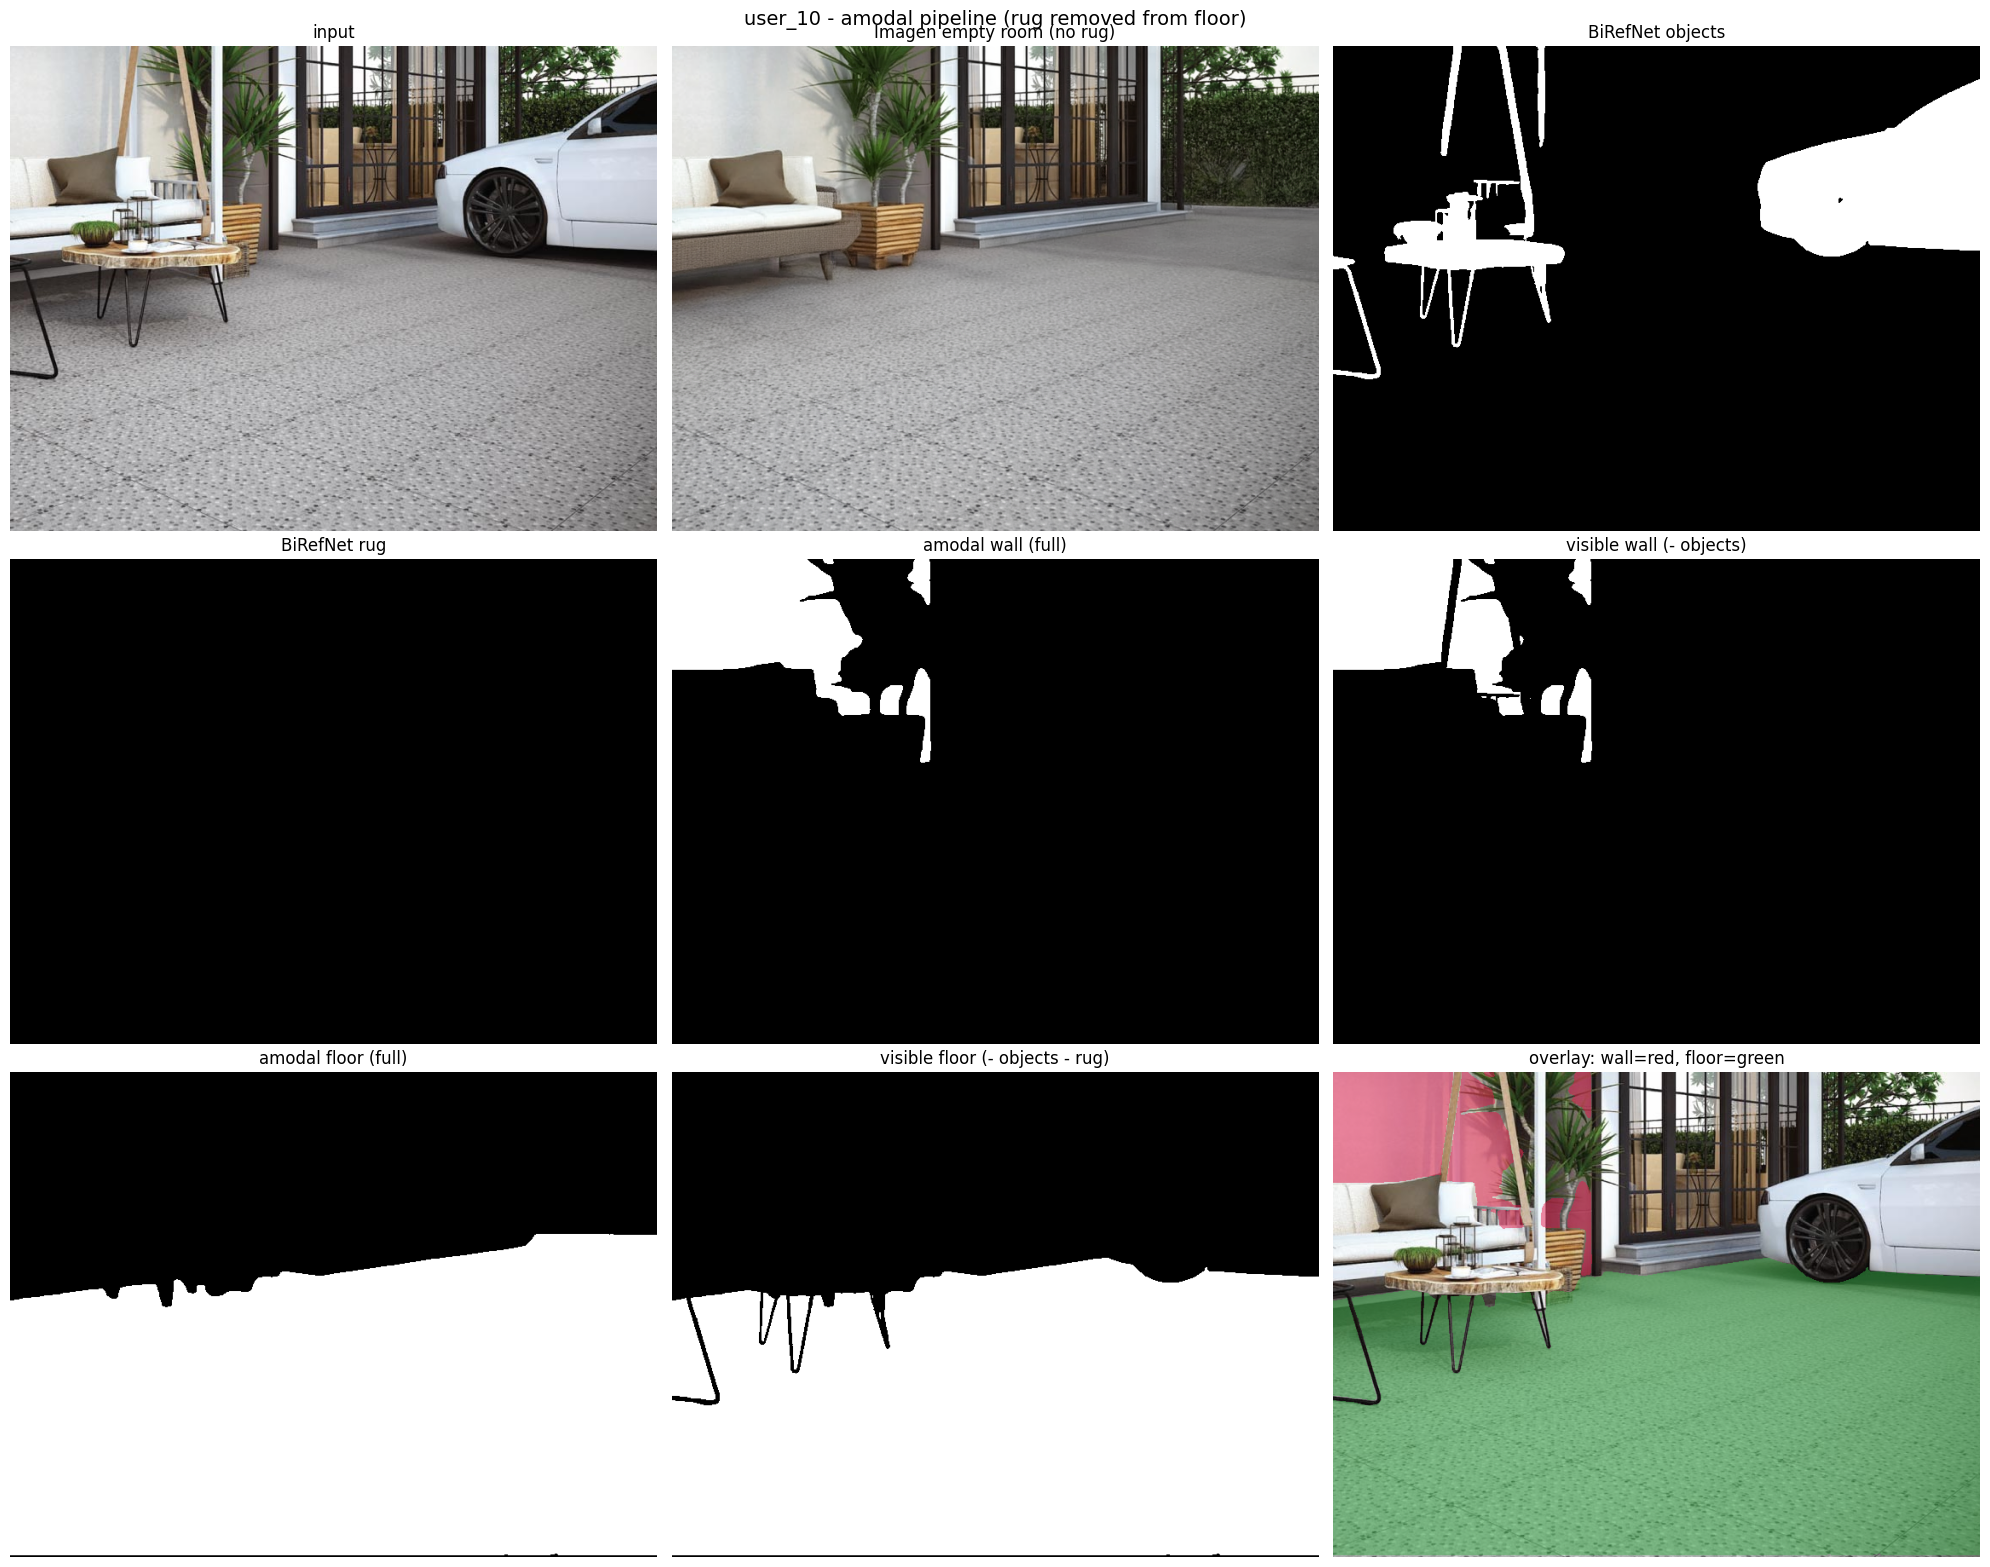

In [41]:
def _overlay(ax, img, masks):
    ax.imshow(img)
    for m, rgb in masks:
        ov = np.zeros((*np.asarray(m).shape, 4))
        ov[..., :3] = np.array(rgb) / 255.0
        ov[..., 3] = (np.asarray(m) > 0) * 0.5
        ax.imshow(ov)
    ax.axis("off")

fig, ax = plt.subplots(3, 3, figsize=(20, 16))
ax[0,0].imshow(res["img"]);                       ax[0,0].set_title("input")
ax[0,1].imshow(res["empty"]);                     ax[0,1].set_title("nano-banana empty room (no rug)")
ax[0,2].imshow(res["objects"], cmap="gray");      ax[0,2].set_title("BiRefNet objects")
ax[1,0].imshow(res["rug"], cmap="gray");          ax[1,0].set_title("BiRefNet rug")
ax[1,1].imshow(res["wall_full"], cmap="gray");    ax[1,1].set_title("amodal wall (full)")
ax[1,2].imshow(res["wall_visible"], cmap="gray"); ax[1,2].set_title("visible wall (- objects)")
ax[2,0].imshow(res["floor_full"], cmap="gray");   ax[2,0].set_title("amodal floor (full)")
ax[2,1].imshow(res["floor_visible"], cmap="gray");ax[2,1].set_title("visible floor (- objects - rug)")
_overlay(ax[2,2], res["img"], [(res["wall_visible"], (230,25,75)),
                               (res["floor_visible"], (60,180,75))])
ax[2,2].set_title("overlay: wall=red, floor=green")
for a in ax.ravel(): a.axis("off")
fig.suptitle(f"{SAMPLE} - amodal pipeline (rug removed from floor)", fontsize=14)
plt.tight_layout(); plt.show()

## Optional: batch (each nano-banana call bills)

In [ ]:
# Batch: run every sample under output-test/ (each nano-banana call bills)
for d in sorted(OUTPUT_DIR.iterdir()):
    if d.name == "user_10":
        if not (d / "original.jpg").exists():
            continue
        print("===", d.name, "===")
        try:
            run_pipeline(d, thresh=0.5)
            print("done", d.name)
        except Exception as e:
            print("FAIL", d.name, ":", type(e).__name__, e)

=== user_10 ===
  moge_start done in 0.7s
  ram_dino_birefnet done in 3.3s
  imagen_empty_room done in 12.2s
  api job 3c480974-a211-4dcc-8ede-51c675a35955 -> /home/krist/works/refine-mask/users/user_10/from-api (11 files)
  api_autodetect done in 10.6s
  decode_visible done in 0.0s
  save_masks_overlay done in 0.1s
  moge job 71594f2b-299d-4ef7-99e7-75e39cab9d0a -> /home/krist/works/refine-mask/users/user_10/moge (10 files)
  moge_fetch done in 3.1s
  TOTAL 30.1s -> /home/krist/works/refine-mask/users/user_10/time.txt
done user_10
